<h1><center>Validating Dynamic Time Warping (shapeDTW) </center></h1>
<h3><center>Kyle Samson, Shuguang Sheng, Wim Pouw</center></h3>
<h3><center>contact: wim.pouw@donders.ru.nl</center></h3>

![](./images/envision_banner.png)

## Info documents

* location Repository: https://github.com/WimPouw/envisionBOX_modulesWP/tree/main/gesture_kinematic

* location Jupyter notebook: https://github.com/WimPouw/envisionBOX_modulesWP/blob/main/MultimodalMerging/gesture_kinematic_spaces.ipynb

### Citation
Pouw, W. (2024). Wim Pouw's EnvisionBOX modules for social signal processing (Version 1.0.0) [Computer software]. https://github.com/WimPouw/envisionBOX_modulesWP

## Background
Human (communicative) body movements are often recurrent, such that they use similar shapes or trajectories to convey or act on something consistently. How can we make sense of the variability and consistency with which movement events are produced? How can determine that two gestures are more or less similar in form? One way to do this is by quantifying the similarities present between all the produced movement events. Once we have documented how similar each movement event is relative to all other events, we can then visualize and quantify the structure of these interrelationships and discover novel patterns that exist over the entire set of behaviors. Furthermore, we can make an informed decision of what gestures are highly similar to each other relative to others. In previous work we have found that when communicative silent gestures have been practiced and communicated more, those silent gestures start to change their interrelationships in consistent ways (e.g., the kinematic space reduces in complexity) (see [3] Pouw, Dingemanse, Motamedi, Ozyurek, 2021).

Note that this particular procedure outlined here, is introduced in [1] Pouw & Dixon (2020) and we advise you to read this first before starting (or [3]). The main procedure: we compute some distance measure between two N-dimenionsal time series *i* and *j*, and do this for all events *n*. Similar to previous work [1] we will use dynamic time warping (see [2] Giorgino, 2009) as the distance calculation. We then compute what is called a distance matrix (**M**) which has *n* rows and *n* columns containing for each cell M[*i*,*j*] the distance score between movement *i* and *j*. Then we can use dimensional reduction techniques (e.g., classic multidimenionsal scaling, t-sne, UMAP, PCA) to visualize in 2-dimensional space the interrelationships between all movement events.

For the current movement events we use a set of silent gestures produced by an actor conveying certain concepts (open dataset by: [4][Ortega & Ozyurek, 2020). We extracted the movement information using mediapipe 3D body tracking for each silent gesture, and this is the input of our procedure. Note that the current procedure can be applied on any signal (e.g., acoustic trajectories) and also on multiple persons that are producing movement events.


## Overview processing steps

This markdown file contains the following processing steps.

* Create a distance matrix with dynamic time warping distances between events

* Perform dimensionality reduction to get a 2D space representing the interrelationships (which will be used to build an app as shown [here](https://envisionbox.org/embedded_dynamicvisualizer.html).

* Create a gesture network, and extract some features to relate to the metadata of Ortega et al.

# Starting up
Lets load some general packages, identify the right folders and show some of the data we are working with.

In [34]:
# loading in some basic packages
import numpy as np     # basic data operations
import pandas as pd    # data wrangling
import matplotlib.pyplot as plt   # for plotting
import plotly.graph_objects as go # for plotting
import html # for html-related add-ons
import os   # for foldering        
from IPython.display import Image # for showing videos
from scipy.ndimage import gaussian_filter1d  # for smoothing

# initializing some folders and files
timeseriesfolder = "../DemonstrationDataOrtega/TimeSeries/"
distancematrixfolder = "../DemonstrationDataOrtega/Distance_matrices/"
videofolder = "../DemonstrationDataOrtega/Videos/WithMotionTracking/"

The folder 'TimeSeries' is filled with mediapipe body tracking time series for each video. We extract from it, nose, elbow, index finger (x , y, z) info (for both hands). Figure 1 shows an example of the kinematic time series for the silent gesture "TO-SWIM" which is also shown below. The swimming gesture has a characteristic rhythmic movement, as reflected in the oscillating movements in the horizontal dimension for left and right index finger. 





Figure 1. Example raw time series of SWIMMING for the right (red) and left hand (in blue)

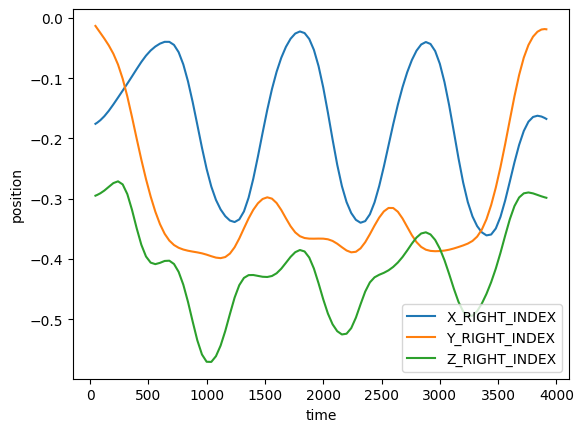

In [35]:
#load in data
gesture = 'TO-SWIM'
MT = pd.read_csv(timeseriesfolder+gesture+"_silentgesture.csv")
MT = MT.apply(lambda x: gaussian_filter1d(x, sigma = 2)) #smooth a little
#plot X_RIGHT_INDEX and Y_RIGHT_INDEX time series with time as x-axis
plt.plot(MT['time'], MT['X_RIGHT_INDEX'], label='X_RIGHT_INDEX')
plt.plot(MT['time'], MT['Y_RIGHT_INDEX'], label='Y_RIGHT_INDEX')
plt.plot(MT['time'], MT['Z_RIGHT_INDEX'], label='Z_RIGHT_INDEX')
plt.xlabel('time')
plt.ylabel('position')
plt.legend()
plt.show()

# show gif
Image(url="./images/"+gesture+".gif")

# DTW

## DTW basics
Dynamic time warping is a method to compare and match two sequences (often time series). It tries to match sequences by allowing for some non-linear distortions in time (or another dimension), so that sequences maximally line up, so as to determine their similarity (after some distortion). This distortation has certain limits and constraints (e.g., such that values matched are not cris-crossing in time) and the degree of time distortions are effectively visualized by a warping path shown below. After matching values in one sequence to another value in the other sequence, one can compute the difference (e.g., euclidean distance between the values) that is still left between these warped sequences. This difference, error, or hereonafter "distance", provides a measure of dissimilarity between two time series. Note dynamic time warping can also compute distances between time series that have more than 1 dimension (as exemplified below). The dynamic time warping distances are best expressed after normalization when time series are known to have unequal lengths (otherwise, distances would add to bigger numbers for longer time series, than shorter one's, though they might be equally similar). The normalization consist in dividing the distance by the length of the timeseries.

## Shape DTW
There are now various variants of DTW. We are using "shape dtw" for this example, which was developed to overcome certain issues with 'classic DTW' having to do with matching segments between timeseries that should not be matched as they are actually quite dissimilar. The inventors of shapeDTW state "Shape-DTW is inherently a DTW algorithm,but additionally attempts to pair locally similar structures and to avoid matching points with distinct neighborhoodstructures", p. 1, for the original paper see [https://arxiv.org/pdf/1606.01601.pdf](here). For a nice introduction with how to set up your DTW pipeline, see here [https://mikolajszafraniecupds.github.io/shapedtw-python/](https://mikolajszafraniecupds.github.io/shapedtw-python/). Shape dtw operates on subsequences of the time series so that it can take into account not only a single point that needs to be matched with the another point in the sequence, but rather take into account the context of the neighboring points too. It therefore favcurrent point that have a similar surrounding values, rather than just single points that have matching values. We set the width of the context at 20 (i.e., 20 timesteps, context of about 800ms assuming a framerate of 25fps), as this seems to provide good matches.

# Other things to consider
There are many other different things that you need to consider when doing dynamic time warping. For example, you if you care about the general shape of a gesture but not its size, then you might want to normalize (e.g., z-scale) the time series first. Or you might not care about the place in gesture space, so you center the the position coordinates first. Also consider, we now only take a few keypoints that might not capture enough of the hand shape or other features, so you can consider adding more keypoints (a the cost of computational time). 

Further, what if you have a gesture consisting of multiple elements, and you want to judge another gesture as similar when it has the same elements regardless of the order of the items? Then you might not want to use dynamic time warping as it will judge a time series with elements a-b-c to be completely different from a time series with elements c-b-a (a possible time series distance measure that does judge such time series to be similar is matrix profile distance or MPdist). 

There are also a range of settings that optimize dynamic time warping performance. For example, you may want to limit the distance error calculation to be based on the begin and trailing portions of the time series as these often are difficult to match, which can be a pesky issue in classic-dtw discussed in [4] (Silva et al 2016; a possible solution for this is psy-dtw). Or it might happen that the warping leads to extreme distortions in time leading to non-sensical matches (a solution for this is limiting the maximum warping constraint, using for example a Sakoe-Chiba window). There are many such optimizations and it would be good to familiarize oneself with these as they can greatly improve performance.

# Further study
This module barely scratches the surface of what is behind dynamic time warping. A nice more in-depth covering of DTW is overviewed here https://www.audiolabs-erlangen.de/resources/MIR/FMP/C3/C3S2_DTWbasic.html, with an open access book chapter https://www.audiolabs-erlangen.de/resources/MIR/FMP/C3/C3S2_DTWbasic.html. Then we would recommend digging further into the specific implimentation used here, which is shape-dtw: https://mikolajszafraniecupds.github.io/shapedtw-python/.

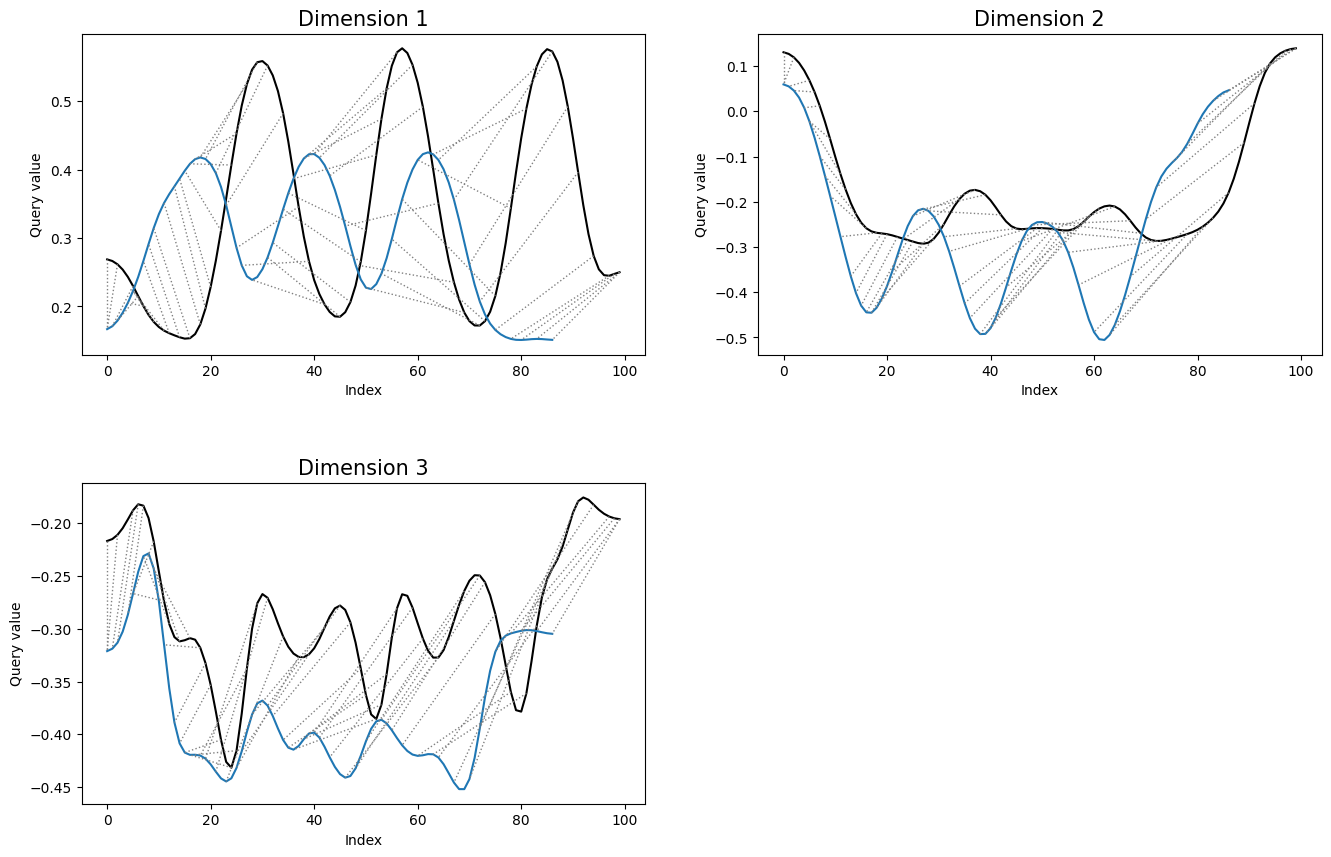

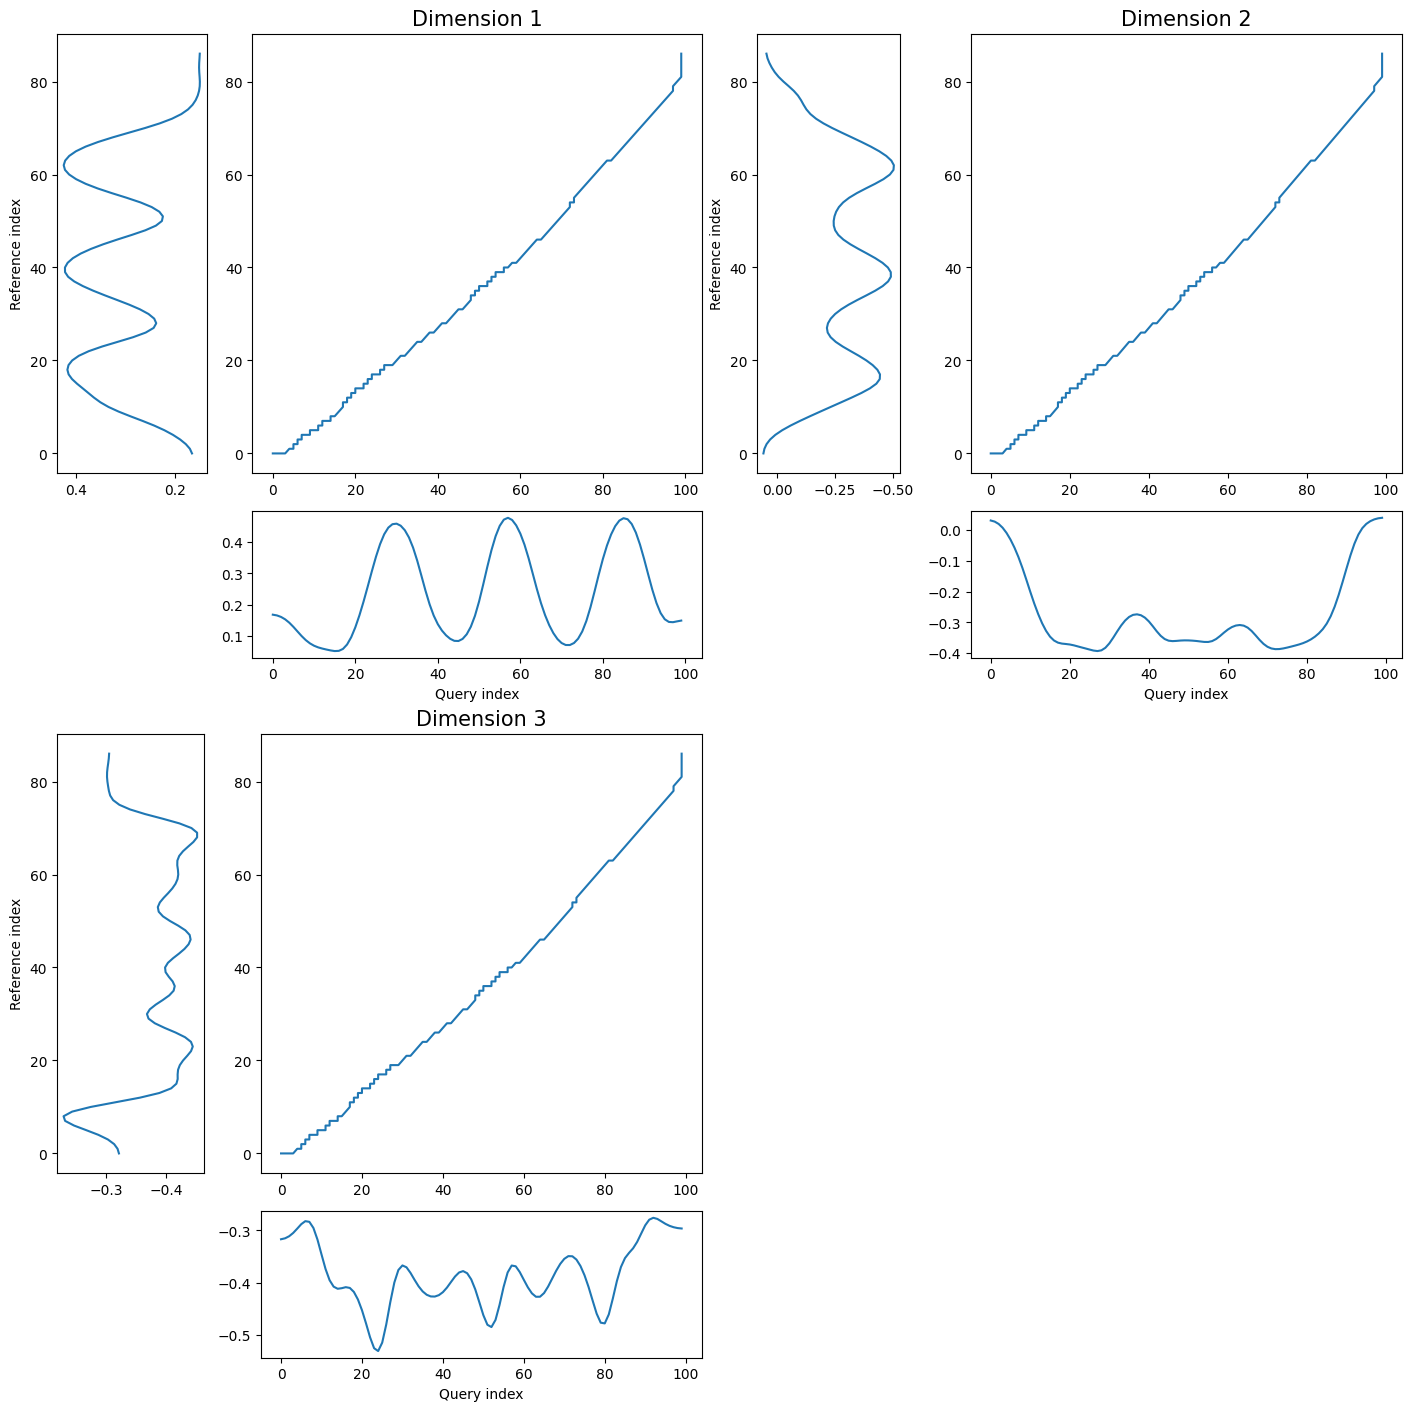

DTW distance is: 29.4
Normalized DTW distance is: 0.15720763433954837


In [36]:
from shapedtw.shapedtw import shape_dtw
from shapedtw.dtwPlot import dtwPlot
from shapedtw.shapeDescriptors import RawSubsequenceDescriptor, SlopeDescriptor, DerivativeShapeDescriptor

# using dtw to compare distances and show a warping line
MT1 = pd.read_csv(timeseriesfolder+"TO-SWIM_silentgesture.csv")
MT2 = pd.read_csv(timeseriesfolder+"BUTTERFLY_silentgesture.csv") #compare example against BANANA
MT1 = MT1.apply(lambda x: gaussian_filter1d(x, sigma = 2)) #smooth a little
MT2 = MT2.apply(lambda x: gaussian_filter1d(x, sigma = 2)) #smooth a little

# select some set of features from the motion tracking dataframe
keypointindexleft = ["X_LEFT_INDEX", "Y_LEFT_INDEX", "Z_LEFT_INDEX"]
ts1 = np.array(MT1[keypointindexleft])
ts2 = np.array(MT2[keypointindexleft])

# setting up the DTW functions
shape_dtw_dependent_results = shape_dtw(
    x=ts1,
    y=ts2,
    subsequence_width=20, # so this means for the matching that we take 20 indices into account
    shape_descriptor=RawSubsequenceDescriptor(), # the local context that is taken to compare to other local context is just the raw values
    multivariate_version="dependent" 
)
dependent_distance = round(shape_dtw_dependent_results.distance, 2)
dependent_distance_normalized = shape_dtw_dependent_results.normalized_distance
dtwPlot(shape_dtw_dependent_results, plot_type="twoway", xoffset=0.1)
dtwPlot(shape_dtw_dependent_results, plot_type="threeway")

print("DTW distance is: " + str(dependent_distance))
print("Normalized DTW distance is: " + str(dependent_distance_normalized))


# Validation


## Validation: Motamedi et al. (2021) — Gesture Evolution Dataset

One principled way to evaluate whether shapeDTW captures something meaningful about gesture similarity is to test it against **independent human judgements**. The dataset by [Motamedi and colleages (2019)](https://www.sciencedirect.com/science/article/abs/pii/S0010027719301234) is suitable for this: it documents how silent gestures for the same concepts evolve across 5 transmission chains and 5 generations of participants, annotated at the symbol level using a formal gesture coding scheme.

### The annotation: `code_string`

Each gesture is described by a `code_string` — a comma-separated sequence of movement components, e.g.:

```
1hKnock<right>, 1hBadge<right>, 2hFists.wristsX
```

This encodes *what* is done (knocking, showing a badge, crossing wrists) in sequence. Two gestures that share many components should look kinematically similar too — this is the hypothesis we test.

We compute two symbolic distance metrics from the code strings:
- **Token-level Levenshtein distance** — how many insertions / deletions / substitutions of gesture components separate the two strings
- **Token-level Jaccard distance** — `1 − |shared components| / |all components|`

We then ask: **do pairs with lower symbolic distance also show lower shapeDTW kinematic distance?** We will restrict our comparisons between gestures that portray the convey target.

In [37]:

import cv2
from PIL import Image as PILImage, ImageDraw   # renamed to avoid shadowing IPython.display.Image
import numpy as np

# Display the GIF inline (IPython.display.Image imported in the first code cell)
Image(url="./Images/arrest_evolution_ch1.gif")


In [38]:
# - Step 1: Settings & data loading
# Set N_COMPARISONS to an integer to draw a random subset (fast),
# or None to run all available pairs (can be tens of thousands — slow).

N_COMPARISONS = 20958 #20958 (will do all later)
RANDOM_SEED   = 40

# - Paths
MOTAMEDI_DIR = "../ValidationDataMotamedi/"
TRACKING_DIR = MOTAMEDI_DIR + "data_tracking_mediapipe/"
PROC_DIR     = MOTAMEDI_DIR + "processed/"

# - Annotation target -> tracking-file prefix
# The tracking filenames start with a short concept key, not the full target name.
# Targets with no tracking files
# are simply omitted — they will be filtered out automatically below.
TARGET_TO_PREFIX = {'chef':'chef', 'frying pan':'fryingpan','to cook':'cook',
    'church': 'church','bible':  'bible', 'to preach':  'preach','photographer':'photographer','darkroom':'darkroom',
    'camera': 'camera','concert hall':'concerthall','microphone':'microphone','hairdresser':'hairdresser',
    'hair salon': 'hairsalon','to give a haircut': 'haircut','police officer':'policeofficer','prison': 'prison',
    'handcuffs':  'handcuffs','to make an arrest': 'arrest',
}

# - Load annotation: all concepts from experiment 1
# gen 0 = seed gesture (no tracking file), so we keep only generation > 0.
# participant = "full{N}" maps to tracking filename suffix "f{N}".
anno = pd.read_csv(MOTAMEDI_DIR + "annotation_data/ex1.csv")
df   = (anno[(anno["generation"] > 0) &
   anno["participant"].str.startswith("full", na=False)]
        .copy())

df["chain_num"] = df["chain"].str.extract(r"(\d+)").astype(int)
df["f_num"]     = df["participant"].str.extract(r"full(\d+)").astype(int)
df["prefix"]    = df["target"].map(TARGET_TO_PREFIX)

# Build path to the body tracking CSV (contains nose, elbows, wrists, index fingers)
df["filepath"] = (TRACKING_DIR + df["prefix"].fillna("__missing__")
       + "_exp1_ch" + df["chain_num"].astype(str)
       + "_g"       + df["generation"].astype(str)
       + "_f"       + df["f_num"].astype(str)
       + "_body.csv")

# gesture_id must match the row/column labels in the precomputed distance matrices
# (spaces in target name → underscores, same as compute_annotation_distances.py)
df["gesture_id"] = ("ex1_ch" + df["chain_num"].astype(str)
  + "_g"   + df["generation"].astype(str)
  + "_"    + df["target"].str.replace(" ", "_", regex=False)
  + "_"    + df["director"].astype(str)
  + "_TI")

# - Load precomputed annotation distance matrices --------------─
lev_mat  = pd.read_csv(PROC_DIR + "ex1_levenshtein.csv", index_col=0)
jacc_mat = pd.read_csv(PROC_DIR + "ex1_jaccard.csv",     index_col=0)

# Keep only rows that have a tracking file AND an entry in the distance matrix
gesture_ok = set(lev_mat.index)
df = (df[df["filepath"].apply(os.path.exists) &
  df["gesture_id"].isin(gesture_ok)]
      .reset_index(drop=True))

print(f"Usable gesture instances : {len(df)}")
print(f"Concepts covered  : {df['target'].nunique()} / {anno['target'].nunique()}")
print(f"Distance matrix size     : {lev_mat.shape[0]} x {lev_mat.shape[1]}")


Usable gesture instances : 870
Concepts covered  : 18 / 24
Distance matrix size     : 1320 x 1320


In [39]:
# - Body keypoints (shoulders kept for centering, dropped after)
KP_BODY = [
    "X_NOSE",        "Y_NOSE",
    "X_LEFT_ELBOW",  "Y_LEFT_ELBOW",
    "X_RIGHT_ELBOW", "Y_RIGHT_ELBOW",
    "X_LEFT_WRIST",  "Y_LEFT_WRIST",
    "X_RIGHT_WRIST", "Y_RIGHT_WRIST",
    "X_LEFT_SHOULDER",  "Y_LEFT_SHOULDER",
    "X_RIGHT_SHOULDER", "Y_RIGHT_SHOULDER",
]

# - Hand keypoints (all fingers, X/Y only)
FINGERS = ["THUMB", "INDEX_FINGER", "MIDDLE_FINGER", "RING_FINGER", "PINKY_FINGER"]
THUMB_JOINTS  = ["CMC", "IP", "TIP"]
FINGER_JOINTS = ["MCP", "DIP", "TIP"]

KP_HANDS = []
for side in ["LEFT", "RIGHT"]:
    KP_HANDS += [f"X_{side}_WRIST", f"Y_{side}_WRIST"]
    for joint in THUMB_JOINTS:
        KP_HANDS += [f"X_{side}_THUMB_{joint}", f"Y_{side}_THUMB_{joint}"]
    for finger in ["INDEX_FINGER", "MIDDLE_FINGER", "RING_FINGER", "PINKY_FINGER"]:
        for joint in FINGER_JOINTS:
            KP_HANDS += [f"X_{side}_{finger}_{joint}", f"Y_{side}_{finger}_{joint}"]

ts_cache   = {}
cols_cache = {}

def load_ts(path):
    """Load body + hands CSVs, center by shoulder midpoint, add finger extension ratios, smooth."""
    if path not in ts_cache:
        # - Load body
        df_body = pd.read_csv(path)
        body_cols = [c for c in KP_BODY if c in df_body.columns]
        df_body = df_body[body_cols].copy()

        # - Load hands
        hand_path = path.replace("_body.csv", "_hands.csv")
        try:
            df_hand = pd.read_csv(hand_path)
            hand_cols = [c for c in KP_HANDS if c in df_hand.columns
                         and c not in df_body.columns]
            df_hand = df_hand[hand_cols].copy()
            n = min(len(df_body), len(df_hand))
            df_body = df_body.iloc[:n].reset_index(drop=True)
            df_hand = df_hand.iloc[:n].reset_index(drop=True)
            df_ts = pd.concat([df_body, df_hand], axis=1).reset_index(drop=True)
        except FileNotFoundError:
            df_ts = df_body.copy().reset_index(drop=True)

        # - Shoulder midpoint centering
        if all(c in df_ts.columns for c in
               ["X_LEFT_SHOULDER", "X_RIGHT_SHOULDER",
                "Y_LEFT_SHOULDER", "Y_RIGHT_SHOULDER"]):
            mid_x = (df_ts["X_LEFT_SHOULDER"] + df_ts["X_RIGHT_SHOULDER"]).values / 2
            mid_y = (df_ts["Y_LEFT_SHOULDER"] + df_ts["Y_RIGHT_SHOULDER"]).values / 2
            for col in df_ts.columns:
                if col.startswith("X_"):   df_ts[col] = df_ts[col].values - mid_x
                elif col.startswith("Y_"): df_ts[col] = df_ts[col].values - mid_y
            df_ts = df_ts.drop(columns=["X_LEFT_SHOULDER", "X_RIGHT_SHOULDER",
                                         "Y_LEFT_SHOULDER", "Y_RIGHT_SHOULDER"])

        # - Per-finger extension ratio
        for side in ["LEFT", "RIGHT"]:
            wx, wy = f"X_{side}_WRIST", f"Y_{side}_WRIST"
            if wx not in df_ts.columns:
                continue
            for finger in FINGERS:
                if finger == "THUMB":
                    mcp_x, mcp_y = f"X_{side}_THUMB_MCP", f"Y_{side}_THUMB_MCP"
                    tip_x, tip_y = f"X_{side}_THUMB_TIP", f"Y_{side}_THUMB_TIP"
                else:
                    mcp_x, mcp_y = f"X_{side}_{finger}_MCP", f"Y_{side}_{finger}_MCP"
                    tip_x, tip_y = f"X_{side}_{finger}_TIP", f"Y_{side}_{finger}_TIP"
                if not all(c in df_ts.columns for c in [mcp_x, mcp_y, tip_x, tip_y]):
                    continue
                mcp_dist = np.sqrt((df_ts[mcp_x].values - df_ts[wx].values)**2 +
                                   (df_ts[mcp_y].values - df_ts[wy].values)**2) + 1e-6
                tip_dist = np.sqrt((df_ts[tip_x].values - df_ts[wx].values)**2 +
                                   (df_ts[tip_y].values - df_ts[wy].values)**2)
                df_ts[f"EXT_{side}_{finger}"] = tip_dist / mcp_dist

        # - Interpolate, smooth
        df_ts = df_ts.interpolate(method="linear", axis=0).ffill().bfill().fillna(0)
        df_ts = df_ts.apply(lambda x: gaussian_filter1d(x, sigma=2))

        ts_cache[path]   = df_ts.values
        cols_cache[path] = list(df_ts.columns)
    return ts_cache[path]


# - Step 2a.5: Global z-score statistics
print("Computing global statistics...")
for path in df["filepath"].unique():
    load_ts(path)

# only use files with full feature set (i.e. hands data present)
n_features_max = max(v.shape[1] for v in ts_cache.values())
valid_paths    = {k for k, v in ts_cache.items() if v.shape[1] == n_features_max}
skipped        = len(ts_cache) - len(valid_paths)
print(f"Skipped {skipped} files without hands data, using {len(valid_paths)} files")

all_data    = np.concatenate([ts_cache[p] for p in valid_paths], axis=0)
global_mean = all_data.mean(axis=0)
global_std  = all_data.std(axis=0) + 1e-8

def normalise_ts(ts):
    return (ts - global_mean) / global_std

print(f"Global stats computed over {all_data.shape[0]} frames, {all_data.shape[1]} features")

# - Step 2b: Sample pairs — same-target only (only from files with full feature set)
all_pairs = [
    (i, j)
    for i in range(len(df))
    for j in range(i + 1, len(df))
    if df.iloc[i]["target"] == df.iloc[j]["target"]
    and df.iloc[i]["filepath"] in valid_paths
    and df.iloc[j]["filepath"] in valid_paths
]

if N_COMPARISONS is not None and N_COMPARISONS < len(all_pairs):
    rng      = np.random.default_rng(RANDOM_SEED)
    selected = [all_pairs[k]
                for k in rng.choice(len(all_pairs), N_COMPARISONS, replace=False)]
else:
    selected = all_pairs

print(f"Total same-target pairs  : {len(all_pairs)}")
print(f"Pairs to evaluate        : {len(selected)}")
print(f"Targets represented      : {df[df['filepath'].isin(valid_paths)]['target'].nunique()}")

Computing global statistics...
Skipped 1 files without hands data, using 869 files
Global stats computed over 86967 frames, 78 features
Total same-target pairs  : 20937
Pairs to evaluate        : 20937
Targets represented      : 18


# The method we want to optimize
The below DTW method is the one applied and that may be assess for performance when changing the hyperparameters. The following hyperparamaters worked well for this context.

So what we do here is we do dependent DTW on each x, y keypoint, and then add them up (which makes it an independent DTW with dependent DTW distance per 2D keypoint timeseries).

In [40]:
# Our DTW method
from shapedtw.shapeDescriptors import RawSubsequenceDescriptor, SlopeDescriptor, DerivativeShapeDescriptor

## Your method
#def my_timeseries_distance(x, y):
#    res = shape_dtw(x=x, y=y,
#            subsequence_width=10, # in frames (so 400 ms subsuequence width)
#                step_pattern="asymmetric",   # relaxes end constraint
#            open_begin=True,
#            open_end=True,
#            shape_descriptor=DerivativeShapeDescriptor(),
#            window_type="sakoechiba", window_args={"window_size": 20}, # (so 800 ms max warp)
#            multivariate_version="dependent")
#    dtw_dist = res.normalized_distance
#    return(dtw_dist)


def my_timeseries_distance(x, y, cols):
    landmarks = {}
    for idx, col in enumerate(cols):
        if col.startswith("X_"):
            landmarks.setdefault(col[2:], {})["x"] = idx
        elif col.startswith("Y_"):
            landmarks.setdefault(col[2:], {})["y"] = idx

    distances = []
    for name, idxs in landmarks.items():
        if "x" not in idxs or "y" not in idxs:
            continue
        res = shape_dtw(
            x=x[:, [idxs["x"], idxs["y"]]],
            y=y[:, [idxs["x"], idxs["y"]]],
            subsequence_width=10,
            step_pattern="asymmetric",
            open_begin=True, open_end=True,
            shape_descriptor=DerivativeShapeDescriptor(),
            window_type="sakoechiba", window_args={"window_size": 20},
            multivariate_version="dependent"
        )
        distances.append(res.normalized_distance)

    return float(np.mean(distances))


In [41]:
# - Step 2c: Run shapeDTW
from tqdm.notebook import tqdm

def mirror_ts(ts, cols):
    """Return a copy of ts with LEFT and RIGHT columns swapped."""
    ts_m = ts.copy()
    for col in cols:
        if "LEFT" in col:
            partner = col.replace("LEFT", "RIGHT")
        elif "RIGHT" in col:
            partner = col.replace("RIGHT", "LEFT")
        else:
            continue
        if partner in cols:
            ci, cp = cols.index(col), cols.index(partner)
            ts_m[:, ci], ts_m[:, cp] = ts[:, cp].copy(), ts[:, ci].copy()
    return ts_m

results = []
for i, j in tqdm(selected, desc="shapeDTW"):
    ri, rj = df.iloc[i], df.iloc[j]

    # load from cache and apply global normalisation
    ts_i   = normalise_ts(load_ts(ri.filepath))
    ts_j   = normalise_ts(load_ts(rj.filepath))
    cols_i = cols_cache[ri.filepath]
    cols_j = cols_cache[rj.filepath]
    try:
        dtw_dist        = my_timeseries_distance(x=ts_i, y=ts_j, cols=cols_i)
        ts_j_mirror     = mirror_ts(ts_j, cols_j)
        dtw_dist_mirror = my_timeseries_distance(x=ts_i, y=ts_j_mirror, cols=cols_i)
        dtw_best        = min(dtw_dist, dtw_dist_mirror)
    except Exception:
        continue

    results.append({
        "dtw":         dtw_best,
        "levenshtein": float(lev_mat.loc[ri.gesture_id, rj.gesture_id]),
        "jaccard":     float(jacc_mat.loc[ri.gesture_id, rj.gesture_id]),
    })

df_res = pd.DataFrame(results).dropna()
print(f"Completed: {len(df_res)} pairs")

shapeDTW:   0%|          | 0/20937 [00:00<?, ?it/s]

KeyboardInterrupt: 

Levenshtein (norm.)        Pearson r=0.046 (p=5.56e-08)  Spearman rho=0.042
Jaccard                    Pearson r=0.280 (p=1.43e-246)  Spearman rho=0.307


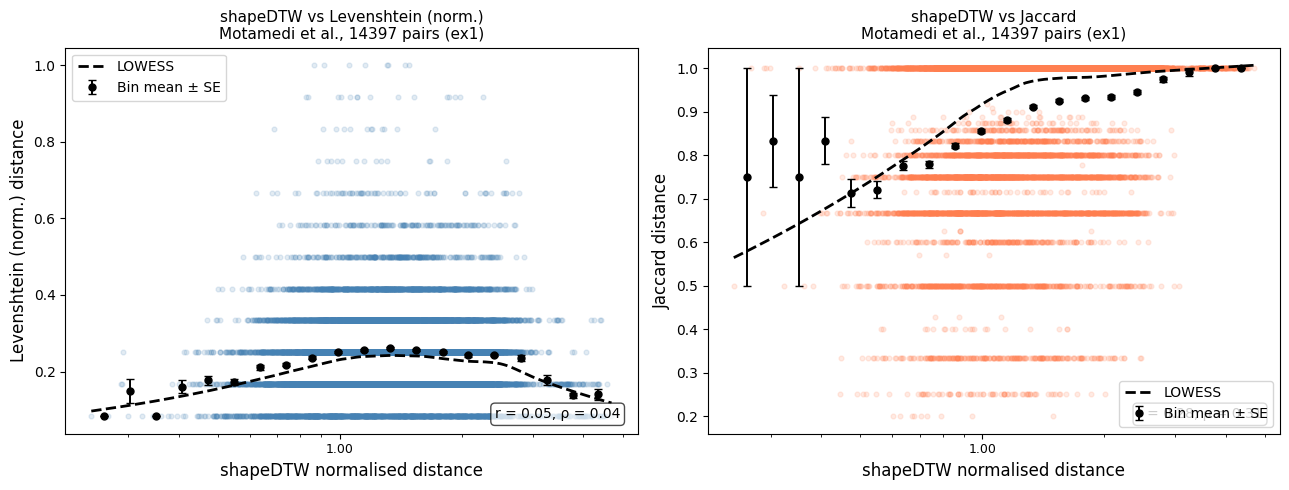

In [ ]:
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from matplotlib.ticker import LogLocator, ScalarFormatter

df_res["lev_norm"] = df_res["levenshtein"] / df_res["levenshtein"].max()

N_BINS = 20

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (col, label, color) in zip(axes, [
    ("lev_norm", "Levenshtein (norm.)", "steelblue"),
    ("jaccard",  "Jaccard",             "coral")
]):
    valid = df_res[["dtw", col]].dropna().copy()
    valid = valid[(valid[col] > 0) & (valid["dtw"] > 0)]

    # - raw scatter
    ax.scatter(valid["dtw"], valid[col],
               alpha=0.15, s=12, color=color, label="_nolegend_")

    # - binned means ± SE (bins in log space)
    valid["bin"] = pd.cut(np.log10(valid["dtw"]), bins=N_BINS)
    bin_stats = valid.groupby("bin", observed=True)[col].agg(["mean", "std", "count"])
    bin_stats["se"] = bin_stats["std"] / np.sqrt(bin_stats["count"])
    bin_centers = 10 ** np.array(bin_stats.index.map(lambda b: float(b.mid)), dtype=float)
    ax.errorbar(bin_centers, bin_stats["mean"], yerr=bin_stats["se"],
                fmt="o", color="black", markersize=5, linewidth=1.4,
                capsize=3, label="Bin mean ± SE", zorder=5)

    # - LOWESS (fitted in log space, plotted on log axes)
    lowess = sm.nonparametric.lowess(
        np.log10(valid[col]), np.log10(valid["dtw"]), frac=0.3)
    ax.plot(10 ** lowess[:, 0].astype(float), 10 ** lowess[:, 1].astype(float),
            color="black", linewidth=2, linestyle="--", label="LOWESS")

    # - log x-axis with reliable tick labels
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.get_major_formatter().set_scientific(False)
    ax.tick_params(axis="x", which="both", labelsize=9)

    # - stats on log-transformed values
    r_p, p_p = pearsonr(np.log10(valid["dtw"]), np.log10(valid[col]))
    r_s, _   = spearmanr(valid["dtw"], valid[col])
    print(f"{label:25s}  Pearson r={r_p:.3f} (p={p_p:.2e})  Spearman rho={r_s:.3f}")
    ax.text(0.97, 0.04,
            f"r = {r_p:.2f}, ρ = {r_s:.2f}",
            transform=ax.transAxes, ha="right", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    ax.set_xlabel("shapeDTW normalised distance", fontsize=12)
    ax.set_ylabel(f"{label} distance", fontsize=12)
    ax.set_title(f'shapeDTW vs {label}\nMotamedi et al., {len(df_res)} pairs (ex1)',
                 fontsize=11)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


## Validation: Akamine et al. (2024) — Gesture Similarity Dataset

A second validation benchmark comes from [Akamine et al. (2024)](https://doi.org/10.3758/s13428-024-02469-y), who collected **human similarity ratings** for pairs of silent gestures produced in a director–matcher task. For a subset of 100 gesture pairs, trained annotators rated similarity on four independent dimensions:

| Dimension | Scale | What it captures |
|-----------|-------|-----------------|
| `location` | 0 – 5 | Where in space the gesture is made |
| `handshape` | 0 – 5 | Configuration of the fingers and palm |
| `orientation` | 0 – 5 | Rotation and facing of the hand |
| `movement` | 0 – 5 | Trajectory and dynamics of the motion |

Higher scores mean the two gestures in the pair are *more similar* on that dimension.  We sum the four scores into a single **total similarity** (0 – 20) and ask: does a lower shapeDTW kinematic distance correspond to a higher total similarity?  We also show Akamine et al.'s own best-performing DTW measure (`average_distance`) for direct comparison.


In [ ]:

# Akamine validation: load data & compute shapeDTW
# KP and load_ts are reused from the Motamedi cells above.
# The 100 sim-coded pairs are small — no sampling needed.

AK_DIR    = "../ValidationDataAkamine/processed/"
AK_TS_DIR = AK_DIR + "timeseries/"

# Load annotation and build total similarity score (higher = more similar)
ak = pd.read_csv(AK_DIR + "gesture_annotation.csv")
ak_sim = ak[ak["location"].notna()].copy()
ak_sim["total_sim"] = ak_sim[["location", "handshape", "orientation", "movement"]].sum(axis=1)

# Compute shapeDTW for every sim-coded pair (reuses KP / load_ts / my_timeseries_distance from above)
ak_results = []
for _, row in tqdm(ak_sim.iterrows(), total=len(ak_sim), desc="shapeDTW (Akamine)"):
    cid    = int(row["comparison_id"])
    path_a = AK_TS_DIR + f"{cid}_1_body.csv"
    path_b = AK_TS_DIR + f"{cid}_2_body.csv"
    ts_a   = load_ts(path_a)
    ts_b   = load_ts(path_b)
    cols_a = cols_cache[path_a]
    cols_b = cols_cache[path_b]
    try:
        dtw_current        = my_timeseries_distance(ts_a, ts_b,        cols_a)
        ts_b_mirror     = mirror_ts(ts_b, cols_b)
        dtw_current_mirror = my_timeseries_distance(ts_a, ts_b_mirror, cols_a)
        dtw_current        = min(dtw_current, dtw_current_mirror)
        ak_results.append({
            "total_sim":   row["total_sim"],
            "dtw_current":    dtw_current,
            "dtw_akamine": row["average_distance"],
        })
    except Exception as e:
        print(f"pair {cid}: {e}")
        continue

ak_df = pd.DataFrame(ak_results).dropna()
print(f"Pairs computed: {len(ak_df)}")


shapeDTW (Akamine):   0%|          | 0/100 [00:00<?, ?it/s]

pair 130: All-NaN slice encountered
pair 143: All-NaN slice encountered
pair 204: All-NaN slice encountered
pair 206: All-NaN slice encountered
pair 211: All-NaN slice encountered
pair 379: All-NaN slice encountered
pair 384: All-NaN slice encountered
pair 433: All-NaN slice encountered
pair 700: All-NaN slice encountered
pair 719: All-NaN slice encountered
pair 841: All-NaN slice encountered
pair 871: All-NaN slice encountered
pair 983: All-NaN slice encountered
pair 1013: All-NaN slice encountered
pair 1072: All-NaN slice encountered
pair 1174: All-NaN slice encountered
Pairs computed: 84


shapeDTW (current)              Pearson r=-0.285 (p=0.009)  Spearman rho=-0.288  slope=-0.2402
Akamine avg. distance           Pearson r=-0.242 (p=0.026)  Spearman rho=-0.308  slope=-0.2073


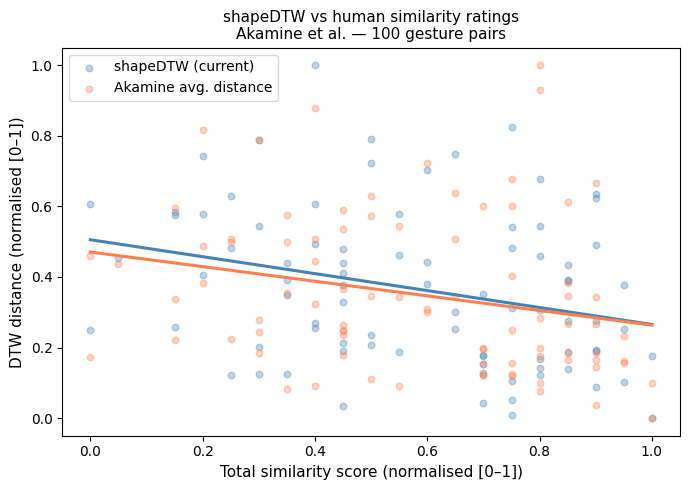

In [ ]:
from sklearn.preprocessing import MinMaxScaler

fig, ax = plt.subplots(figsize=(7, 5))

def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

x_raw = ak_df["total_sim"]
x_norm = minmax(x_raw)

for col, label, color in [("dtw_current",    "shapeDTW (current)",       "steelblue"),
                           ("dtw_akamine", "Akamine avg. distance", "coral")]:
    y_norm = minmax(ak_df[col])
    
    ax.scatter(x_norm, y_norm, alpha=0.35, s=22, color=color, label=label)
    m, b  = np.polyfit(x_norm, y_norm, 1)
    xline = np.linspace(x_norm.min(), x_norm.max(), 200)
    ax.plot(xline, m * xline + b, color=color, linewidth=2.2)
    r_p, p_p = pearsonr(x_norm, y_norm)
    r_s, _   = spearmanr(x_norm, y_norm)
    print(f"{label:30s}  Pearson r={r_p:.3f} (p={p_p:.3f})  Spearman rho={r_s:.3f}  slope={m:.4f}")

ax.set_xlabel("Total similarity score (normalised [0–1])", fontsize=11)
ax.set_ylabel("DTW distance (normalised [0–1])", fontsize=11)
ax.set_title("shapeDTW vs human similarity ratings\nAkamine et al. — 100 gesture pairs", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

1. Pouw, W. , & Dixon, J. A. (2020). Gesture networks: Introducing dynamic time warping and network analysis for the kinematic study of gesture ensembles. Disccurrente Processes, 57(4), 301-319. doi: 10.1080/0163853X.2019.1678967

2. Pouw, W. , Dingemanse, M., Motamedi, Y., Özyürek, A. (2021). A systematic investigation of gesture kinematics in evolving manual languages in the lab. Cognitive Science. doi (open access): 10.1111/cogs.13014

3. Ortega, G., & Özyürek, A. (2020). Systematic mappings between semantic categories and types of iconic representations in the manual modality: A normed database of silent gesture. Behavior Research Methods, 52(1), 51-67.

4. Silva, D. F., Batista, G. A. E. P. A., & Keogh, E. (2016). On the effect of endpoints on dynamic time warping. SIGKDD Workshop on Mining and Learning from Time Series, II. San Francisco, USA.